# 운전 적성 검사 - Cut-point 분석 및 Indicator Feature 생성
---
## 목표: 위험비율이 튀는 구간을 정확히 찾아 Indicator Feature 만들기

## 1. 환경 설정

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

print("환경 설정 완료!")

환경 설정 완료!


In [2]:
# 데이터 로드
train_meta = pd.read_csv("./data/train.csv")
train_A_raw = pd.read_csv("./data/train/A.csv")
train_B_raw = pd.read_csv("./data/train/B.csv")

overall_risk = train_meta['Label'].mean()
print(f"전체 위험군 비율: {overall_risk:.4f}")
print(f"A검사 샘플: {len(train_A_raw)}, B검사 샘플: {len(train_B_raw)}")

전체 위험군 비율: 0.0289
A검사 샘플: 647241, B검사 샘플: 297526


## 2. 유틸 함수 (script04 기반)

In [3]:
def convert_age(val):
    if pd.isna(val):
        return np.nan
    try:
        base = int(str(val)[:-1])
        return base if str(val)[-1].lower() == "a" else base + 5
    except:
        return np.nan

def seq_mean(series):
    s = series.fillna("").astype(str)
    df = s.str.split(",", expand=True).replace("", np.nan).astype(float)
    return df.mean(axis=1)

def seq_std(series):
    s = series.fillna("").astype(str)
    df = s.str.split(",", expand=True).replace("", np.nan).astype(float)
    return df.std(axis=1)

def seq_rate(series, target="1"):
    def calc(x):
        if not x:
            return np.nan
        items = str(x).split(",")
        return items.count(str(target)) / len(items) if items else np.nan
    return series.fillna("").apply(calc)

def masked_mean(cond_series, val_series, mask_val):
    cond_df = cond_series.fillna("").str.split(",", expand=True).replace("", np.nan).astype(float)
    val_df = val_series.fillna("").str.split(",", expand=True).replace("", np.nan).astype(float)
    mask = (cond_df == mask_val)
    return val_df.where(mask).mean(axis=1)

print("유틸 함수 정의 완료!")

유틸 함수 정의 완료!


## 3. A검사 기본 피처 생성

In [4]:
# A검사 전처리
A_df = train_A_raw.copy()
A_df = A_df.merge(train_meta[['Test_id', 'Label']], on='Test_id', how='left')

# Age
A_df['Age_num'] = A_df['Age'].map(convert_age)
A_df['Age_z'] = (A_df['Age_num'] - A_df['Age_num'].mean()) / A_df['Age_num'].std()

# A1 (주의집중, 반응속도)
A_df['A1_resp_rate'] = seq_rate(A_df['A1-3'], '1')
A_df['A1_rt_mean'] = seq_mean(A_df['A1-4'])
A_df['A1_rt_std'] = seq_std(A_df['A1-4'])
A_df['A1_rt_cv'] = A_df['A1_rt_std'] / (A_df['A1_rt_mean'] + 1e-6)

# A4 (Stroop 과제)
A_df['A4_acc_rate'] = seq_rate(A_df['A4-3'], '1')
A_df['A4_rt_mean'] = seq_mean(A_df['A4-5'])
A_df['A4_stroop_diff'] = (
    masked_mean(A_df['A4-1'], A_df['A4-5'], 2) - 
    masked_mean(A_df['A4-1'], A_df['A4-5'], 1)
)

# A5 (변화 탐지)
A_df['A5_acc_rate'] = seq_rate(A_df['A5-2'], '1')
A_df['A5_acc_nonchange'] = masked_mean(A_df['A5-1'], A_df['A5-2'], 1)
A_df['A5_acc_change'] = pd.concat([
    masked_mean(A_df['A5-1'], A_df['A5-2'], 2),
    masked_mean(A_df['A5-1'], A_df['A5-2'], 3),
    masked_mean(A_df['A5-1'], A_df['A5-2'], 4)
], axis=1).mean(axis=1)
A_df['A5_change_nonchange_gap'] = A_df['A5_acc_change'] - A_df['A5_acc_nonchange']

# A6, A7, A9 종합 점수
a6_cols = [c for c in A_df.columns if c.startswith('A6-')]
a7_cols = [c for c in A_df.columns if c.startswith('A7-')]
a9_cols = [c for c in A_df.columns if c.startswith('A9-')]

if a6_cols:
    A_df['A6_total'] = A_df[a6_cols].sum(axis=1)
if a7_cols:
    A_df['A7_total'] = A_df[a7_cols].sum(axis=1)
if a9_cols:
    A_df['A9_total'] = A_df[a9_cols].sum(axis=1)

# 인지/정서 점수
A_df['CogScore_A'] = 0
if 'A6_total' in A_df.columns:
    A_df['CogScore_A'] += A_df['A6_total']
if 'A7_total' in A_df.columns:
    A_df['CogScore_A'] += A_df['A7_total']
if 'A9-4' in A_df.columns:
    A_df['CogScore_A'] += A_df['A9-4'].fillna(0)

A_df['EmoScore_A'] = 0
for col in ['A9-1', 'A9-2', 'A9-5']:
    if col in A_df.columns:
        A_df['EmoScore_A'] += A_df[col].fillna(0)

print(f"A검사 피처 생성 완료: {A_df.shape}")
print(f"Label 결측: {A_df['Label'].isnull().sum()}")

A검사 피처 생성 완료: (647241, 56)
Label 결측: 0


## 4. B검사 기본 피처 생성

In [5]:
# B검사 전처리
B_df = train_B_raw.copy()
B_df = B_df.merge(train_meta[['Test_id', 'Label']], on='Test_id', how='left')

# Age
B_df['Age_num'] = B_df['Age'].map(convert_age)
B_df['Age_z'] = (B_df['Age_num'] - B_df['Age_num'].mean()) / B_df['Age_num'].std()

# B3, B4 (주의집중, Stroop-like)
B_df['B3_acc_rate'] = seq_rate(B_df['B3-1'], '1')
B_df['B3_rt_mean'] = seq_mean(B_df['B3-2'])
B_df['B3_rt_std'] = seq_std(B_df['B3-2'])

B_df['B4_acc_rate'] = seq_rate(B_df['B4-1'], '1')
B_df['B4_rt_mean'] = seq_mean(B_df['B4-2'])
B_df['B4_rt_std'] = seq_std(B_df['B4-2'])

# B9, B10 (지속 주의력, 이중과제)
if all(c in B_df.columns for c in ['B9-1', 'B9-2', 'B9-3', 'B9-4', 'B9-5']):
    B9_AUD_TARGET = 15.0
    B9_AUD_DIST = 35.0
    B_df['B9_aud_overall_acc'] = (
        (B_df['B9-1'].astype(float) + B_df['B9-4'].astype(float)) / (B9_AUD_TARGET + B9_AUD_DIST)
    )
    B_df['B9_vis_err_rate'] = B_df['B9-5'].astype(float) / 32.0

if all(c in B_df.columns for c in ['B10-1', 'B10-2', 'B10-3', 'B10-4', 'B10-5']):
    B10_AUD_TARGET = 20.0
    B10_AUD_DIST = 60.0
    B_df['B10_aud_overall_acc'] = (
        (B_df['B10-1'].astype(float) + B_df['B10-4'].astype(float)) / (B10_AUD_TARGET + B10_AUD_DIST)
    )
    B_df['B10_vis1_err_rate'] = B_df['B10-5'].astype(float) / 52.0
    
    if 'B9_aud_overall_acc' in B_df.columns:
        B_df['B10_multitask_cost_aud'] = B_df['B10_aud_overall_acc'] - B_df['B9_aud_overall_acc']
    if 'B9_vis_err_rate' in B_df.columns:
        B_df['B10_multitask_cost_vis'] = B_df['B10_vis1_err_rate'] - B_df['B9_vis_err_rate']

# RiskScore_B (script04 기반)
eps = 1e-6
B_df['B4_rt_cv'] = B_df['B4_rt_std'] / (B_df['B4_rt_mean'] + eps)
B_df['B3_speed_acc_tradeoff'] = B_df['B3_rt_mean'] / (B_df['B3_acc_rate'] + eps)
B_df['B4_speed_acc_tradeoff'] = B_df['B4_rt_mean'] / (B_df['B4_acc_rate'] + eps)

B_df['RiskScore_B'] = (
    0.25 * B_df['B4_rt_cv'].fillna(0) +
    0.25 * (1 - B_df['B3_acc_rate'].fillna(0)) +
    0.25 * (1 - B_df['B4_acc_rate'].fillna(0)) +
    0.25 * B_df['B3_speed_acc_tradeoff'].fillna(0)
)

print(f"B검사 피처 생성 완료: {B_df.shape}")
print(f"Label 결측: {B_df['Label'].isnull().sum()}")

B검사 피처 생성 완료: (297526, 50)
Label 결측: 0


## 5. 핵심: 구간별 위험비율 분석 함수

In [6]:
def analyze_bins(df, col, label_col='Label', bins=10, method='quantile'):
    """
    특정 컬럼을 구간으로 나눠서 위험비율 분석
    
    Parameters:
    -----------
    df : DataFrame
    col : str - 분석할 컬럼명
    label_col : str - 타겟 컬럼명
    bins : int or list - 구간 수 또는 구간 경계값
    method : str - 'quantile' (qcut) or 'uniform' (cut)
    
    Returns:
    --------
    DataFrame - bin별 위험비율, 샘플 수, 구간 경계
    """
    tmp = df[[col, label_col]].dropna().copy()
    
    if len(tmp) == 0:
        print(f"⚠️  {col}: 데이터 없음")
        return None
    
    try:
        if method == 'quantile':
            tmp['bin'] = pd.qcut(tmp[col], q=bins, duplicates='drop')
        else:
            tmp['bin'] = pd.cut(tmp[col], bins=bins, duplicates='drop')
    except Exception as e:
        print(f"⚠️  {col}: binning 실패 - {e}")
        return None
    
    result = tmp.groupby('bin', observed=True).agg({
        label_col: ['mean', 'count']
    }).reset_index()
    
    result.columns = ['bin', 'risk_rate', 'count']
    result['risk_rate'] = result['risk_rate'].round(5)
    result['coverage'] = (result['count'] / len(tmp) * 100).round(2)
    
    # 구간 경계 추출
    result['left'] = result['bin'].apply(lambda x: x.left)
    result['right'] = result['bin'].apply(lambda x: x.right)
    
    return result

def plot_bin_analysis(result, col, overall_risk, figsize=(14, 5)):
    """
    구간별 위험비율 시각화
    """
    if result is None or len(result) == 0:
        return
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # 위험비율 bar plot
    x = np.arange(len(result))
    axes[0].bar(x, result['risk_rate'], color='coral', alpha=0.7, edgecolor='black')
    axes[0].axhline(y=overall_risk, color='red', linestyle='--', linewidth=2, label=f'Overall: {overall_risk:.4f}')
    axes[0].set_xlabel('Bin')
    axes[0].set_ylabel('Risk Rate')
    axes[0].set_title(f'{col} - Risk Rate by Bin', fontsize=12, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f'{i+1}' for i in range(len(result))], rotation=0)
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # 샘플 수
    axes[1].bar(x, result['count'], color='steelblue', alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Bin')
    axes[1].set_ylabel('Sample Count')
    axes[1].set_title(f'{col} - Sample Count by Bin', fontsize=12, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f'{i+1}' for i in range(len(result))], rotation=0)
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def find_spike_threshold(result, spike_factor=1.5):
    """
    위험비율이 튀는 구간의 threshold 찾기
    
    Parameters:
    -----------
    result : DataFrame - analyze_bins 결과
    spike_factor : float - 전체 평균 대비 몇 배 이상이면 '튐'으로 볼지
    
    Returns:
    --------
    dict - {'low_threshold': float, 'high_threshold': float}
    """
    if result is None or len(result) == 0:
        return None
    
    overall = result['risk_rate'].mean()
    spike_threshold = overall * spike_factor
    
    high_risk_bins = result[result['risk_rate'] >= spike_threshold]
    
    thresholds = {}
    
    if len(high_risk_bins) > 0:
        # 가장 낮은 high risk bin의 left 값
        low_cut = high_risk_bins['left'].min()
        # 가장 높은 high risk bin의 right 값
        high_cut = high_risk_bins['right'].max()
        
        thresholds['low_threshold'] = low_cut
        thresholds['high_threshold'] = high_cut
        thresholds['spike_bins'] = len(high_risk_bins)
        thresholds['max_risk_rate'] = high_risk_bins['risk_rate'].max()
    
    return thresholds

print("구간 분석 함수 정의 완료!")

구간 분석 함수 정의 완료!


## 6. A검사 핵심 피처 구간 분석

### 6.1 A4_acc_rate (정확도)


[A검사] A4_acc_rate 구간 분석


[10분위 quantile 기준]
               bin  risk_rate   count  coverage   left  right
0  (-0.001, 0.962]    0.02706   80609     12.45 -0.001  0.962
1   (0.962, 0.975]    0.02345   96786     14.95  0.962  0.975
2   (0.975, 0.988]    0.02253  183364     28.33  0.975  0.988
3     (0.988, 1.0]    0.02133  286482     44.26  0.988  1.000


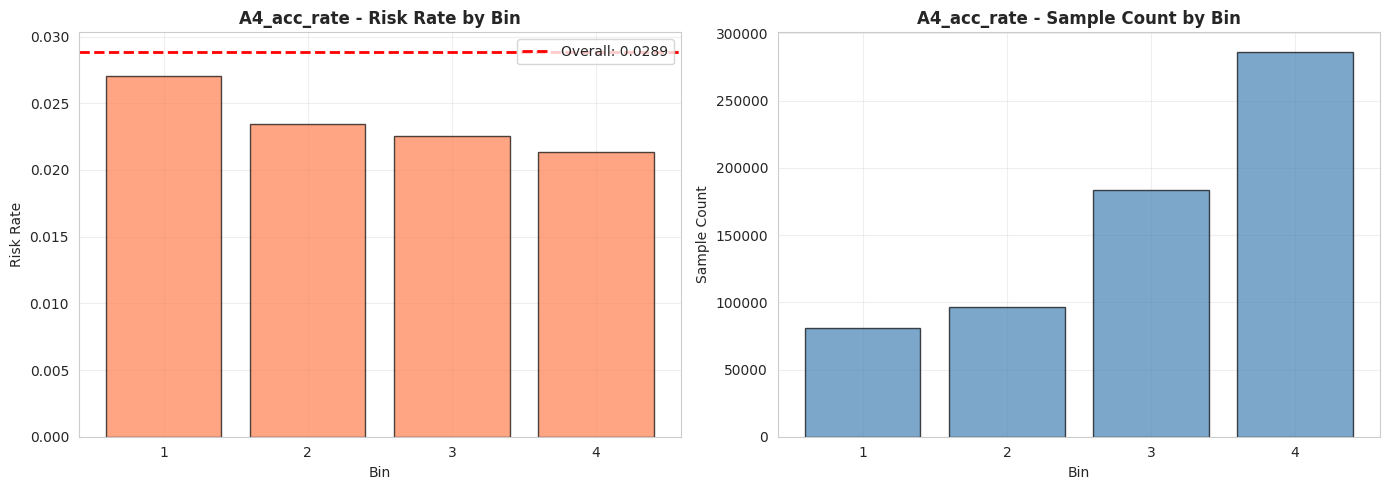


[커스텀 구간 분석]
           bin  risk_rate   count  coverage
0   (0.0, 0.6]    0.06098     164      0.03
1   (0.6, 0.7]    0.05714      70      0.01
2   (0.7, 0.8]    0.06926     231      0.04
3  (0.8, 0.85]    0.02851     491      0.08
4  (0.85, 0.9]    0.03423    2863      0.44
5  (0.9, 0.95]    0.02819   34299      5.30
6  (0.95, 1.0]    0.02230  609119     94.11


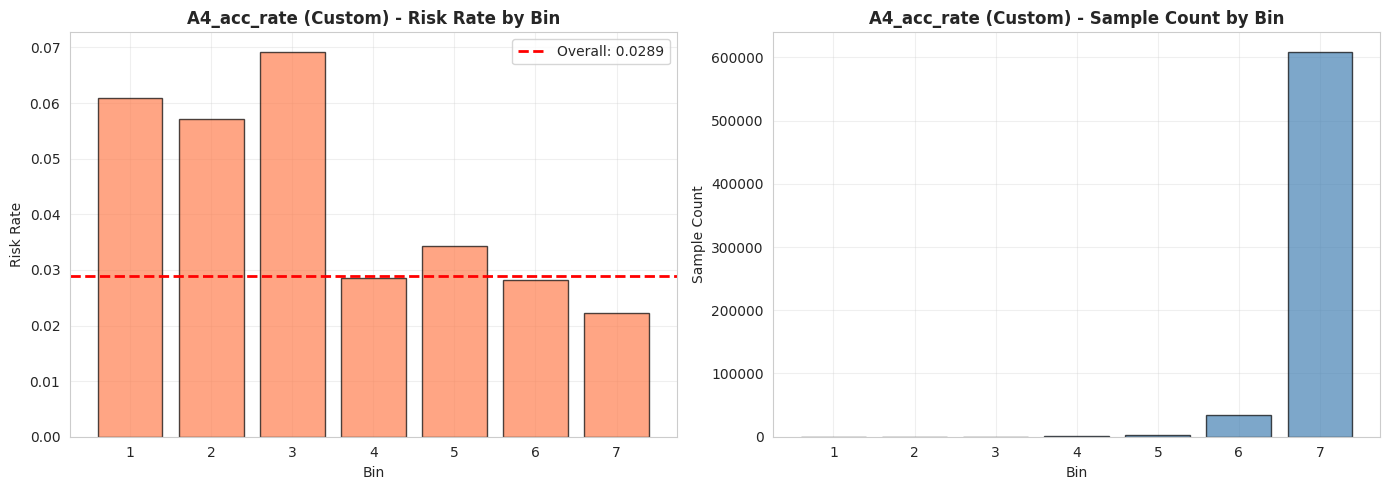

In [7]:
col = 'A4_acc_rate'
print(f"\n{'='*80}")
print(f"[A검사] {col} 구간 분석")
print(f"{'='*80}\n")

# 10분위로 분석
result = analyze_bins(A_df, col, bins=10, method='quantile')
if result is not None:
    print("\n[10분위 quantile 기준]")
    print(result[['bin', 'risk_rate', 'count', 'coverage', 'left', 'right']])
    plot_bin_analysis(result, col, overall_risk)
    
    # Threshold 찾기
    thresholds = find_spike_threshold(result, spike_factor=1.5)
    if thresholds:
        print(f"\n[Spike 구간 분석] (전체 평균의 1.5배 이상)")
        print(f"  - Low threshold: {thresholds['low_threshold']:.4f}")
        print(f"  - High threshold: {thresholds['high_threshold']:.4f}")
        print(f"  - Spike bins: {thresholds['spike_bins']}개")
        print(f"  - Max risk rate: {thresholds['max_risk_rate']:.4f}")

# 커스텀 bins로도 시도
custom_bins = [0, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 1.0]
result_custom = analyze_bins(A_df, col, bins=custom_bins, method='uniform')
if result_custom is not None:
    print("\n[커스텀 구간 분석]")
    print(result_custom[['bin', 'risk_rate', 'count', 'coverage']])
    plot_bin_analysis(result_custom, f"{col} (Custom)", overall_risk)

### 6.2 A4_stroop_diff (Stroop 효과)


[A검사] A4_stroop_diff 구간 분석


[10분위 quantile 기준]
                             bin  risk_rate  count  coverage     left  \
0  (-643.0509999999999, -14.175]    0.02316  64737     10.00 -643.051   
1              (-14.175, -12.95]    0.02259  64725     10.00  -14.175   
2                (-12.95, 0.425]    0.02101  64779     10.01  -12.950   
3                 (0.425, 9.775]    0.02126  64667      9.99    0.425   
4                 (9.775, 17.85]    0.02082  64734     10.00    9.775   
5                 (17.85, 25.55]    0.02190  64807     10.01   17.850   
6                (25.55, 33.775]    0.02197  64625      9.98   25.550   
7                 (33.775, 43.5]    0.02234  64741     10.00   33.775   
8                  (43.5, 57.85]    0.02374  64703     10.00   43.500   
9                (57.85, 2332.5]    0.02821  64723     10.00   57.850   

      right  
0   -14.175  
1   -12.950  
2     0.425  
3     9.775  
4    17.850  
5    25.550  
6    33.775  
7    43.500  
8    57.850  
9  2332

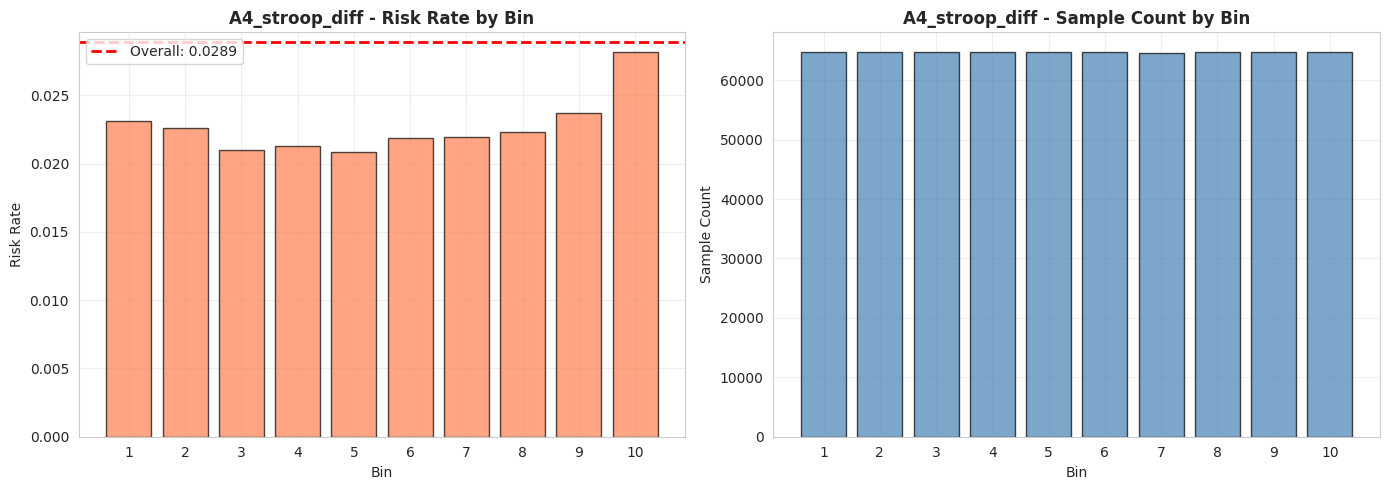

In [8]:
col = 'A4_stroop_diff'
print(f"\n{'='*80}")
print(f"[A검사] {col} 구간 분석")
print(f"{'='*80}\n")

result = analyze_bins(A_df, col, bins=10, method='quantile')
if result is not None:
    print("\n[10분위 quantile 기준]")
    print(result[['bin', 'risk_rate', 'count', 'coverage', 'left', 'right']])
    plot_bin_analysis(result, col, overall_risk)
    
    thresholds = find_spike_threshold(result, spike_factor=1.5)
    if thresholds:
        print(f"\n[Spike 구간 분석]")
        print(f"  - Low threshold: {thresholds['low_threshold']:.4f}")
        print(f"  - High threshold: {thresholds['high_threshold']:.4f}")
        print(f"  - Max risk rate: {thresholds['max_risk_rate']:.4f}")

### 6.3 A1_rt_mean (반응시간)


[A검사] A1_rt_mean 구간 분석


[10분위 quantile 기준]
                   bin  risk_rate  count  coverage     left    right
0  (-727.779, -69.667]    0.02754  64823     10.02 -727.779  -69.667
1   (-69.667, -45.667]    0.02231  64734     10.00  -69.667  -45.667
2   (-45.667, -42.111]    0.02245  73310     11.33  -45.667  -42.111
3   (-42.111, -28.556]    0.02139  56141      8.67  -42.111  -28.556
4   (-28.556, -14.944]    0.02095  64833     10.02  -28.556  -14.944
5    (-14.944, -1.944]    0.02009  64562      9.97  -14.944   -1.944
6     (-1.944, 12.222]    0.02118  64674      9.99   -1.944   12.222
7     (12.222, 30.389]    0.02180  64804     10.01   12.222   30.389
8     (30.389, 53.333]    0.02195  64654      9.99   30.389   53.333
9    (53.333, 654.722]    0.02718  64706     10.00   53.333  654.722


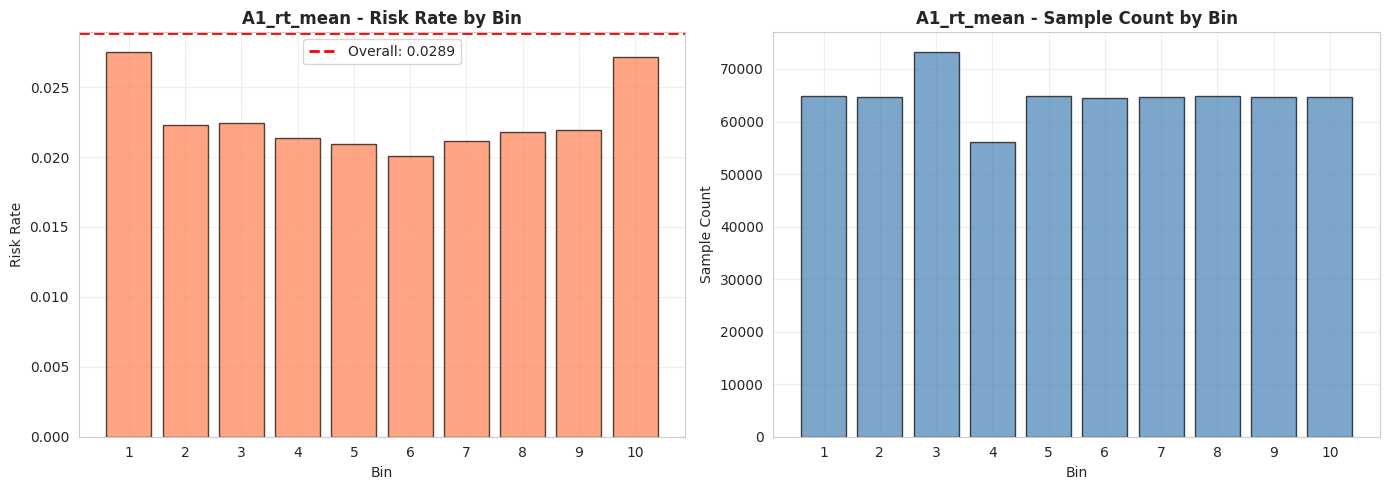

In [9]:
col = 'A1_rt_mean'
print(f"\n{'='*80}")
print(f"[A검사] {col} 구간 분석")
print(f"{'='*80}\n")

result = analyze_bins(A_df, col, bins=10, method='quantile')
if result is not None:
    print("\n[10분위 quantile 기준]")
    print(result[['bin', 'risk_rate', 'count', 'coverage', 'left', 'right']])
    plot_bin_analysis(result, col, overall_risk)
    
    thresholds = find_spike_threshold(result, spike_factor=1.3)
    if thresholds:
        print(f"\n[Spike 구간 분석]")
        print(f"  - Low threshold: {thresholds['low_threshold']:.2f} ms")
        print(f"  - High threshold: {thresholds['high_threshold']:.2f} ms")
        print(f"  - Max risk rate: {thresholds['max_risk_rate']:.4f}")

### 6.4 A5_change_nonchange_gap


[A검사] A5_change_nonchange_gap 구간 분석


[10분위 quantile 기준]
              bin  risk_rate   count  coverage   left  right
0   (-1.001, 0.0]    0.02285   68744     10.62 -1.001  0.000
1    (0.0, 0.111]    0.01801   78462     12.12  0.000  0.111
2  (0.111, 0.167]    0.01911   63162      9.76  0.111  0.167
3  (0.167, 0.222]    0.02146  127236     19.66  0.167  0.222
4  (0.222, 0.278]    0.02027   68468     10.58  0.222  0.278
5  (0.278, 0.333]    0.02288   65294     10.09  0.278  0.333
6  (0.333, 0.389]    0.02494   57088      8.82  0.333  0.389
7    (0.389, 0.5]    0.02705   78329     12.10  0.389  0.500
8      (0.5, 1.0]    0.03327   40456      6.25  0.500  1.000


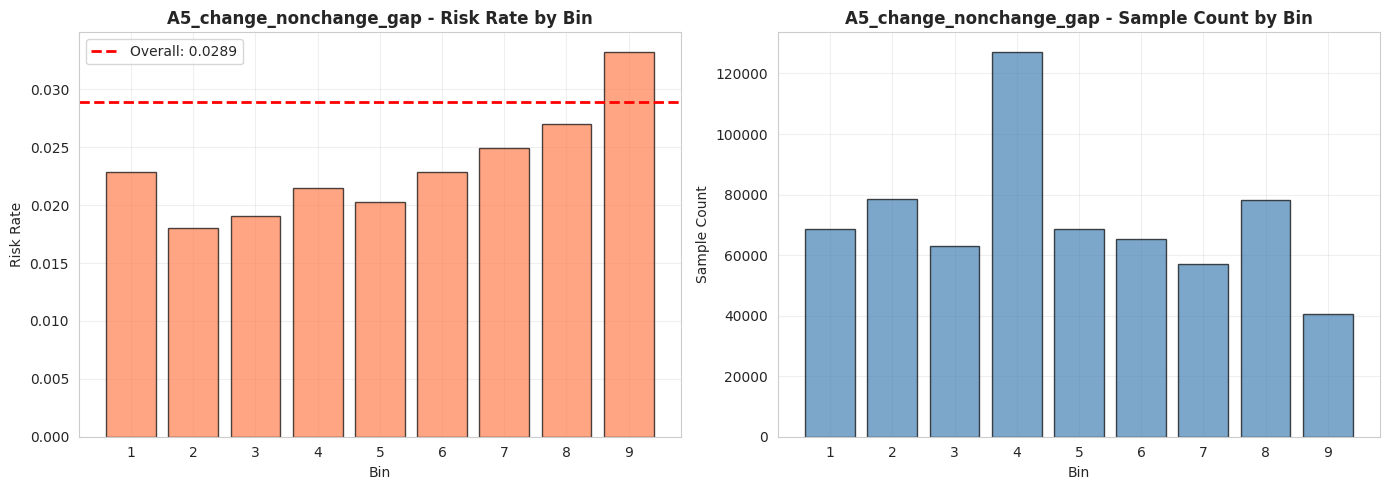

In [10]:
col = 'A5_change_nonchange_gap'
print(f"\n{'='*80}")
print(f"[A검사] {col} 구간 분석")
print(f"{'='*80}\n")

result = analyze_bins(A_df, col, bins=10, method='quantile')
if result is not None:
    print("\n[10분위 quantile 기준]")
    print(result[['bin', 'risk_rate', 'count', 'coverage', 'left', 'right']])
    plot_bin_analysis(result, col, overall_risk)
    
    thresholds = find_spike_threshold(result, spike_factor=1.5)
    if thresholds:
        print(f"\n[Spike 구간 분석]")
        print(f"  - Low threshold: {thresholds['low_threshold']:.4f}")
        print(f"  - High threshold: {thresholds['high_threshold']:.4f}")
        print(f"  - Max risk rate: {thresholds['max_risk_rate']:.4f}")

### 6.5 CogScore_A (인지 점수)


[A검사] CogScore_A 구간 분석


[10분위 quantile 기준]
             bin  risk_rate  count  coverage    left right
0  (0.999, 20.0]    0.03529  78748     12.17   0.999  20.0
1   (20.0, 23.0]    0.02931  58521      9.04  20.000  23.0
2   (23.0, 26.0]    0.02508  79421     12.27  23.000  26.0
3   (26.0, 28.0]    0.02211  63595      9.83  26.000  28.0
4   (28.0, 30.0]    0.01977  67829     10.48  28.000  30.0
5   (30.0, 32.0]    0.02017  64106      9.90  30.000  32.0
6   (32.0, 34.0]    0.01874  54421      8.41  32.000  34.0
7   (34.0, 37.0]    0.01867  67182     10.38  34.000  37.0
8   (37.0, 41.0]    0.01700  58467      9.03  37.000  41.0
9   (41.0, 81.0]    0.01634  54951      8.49  41.000  81.0


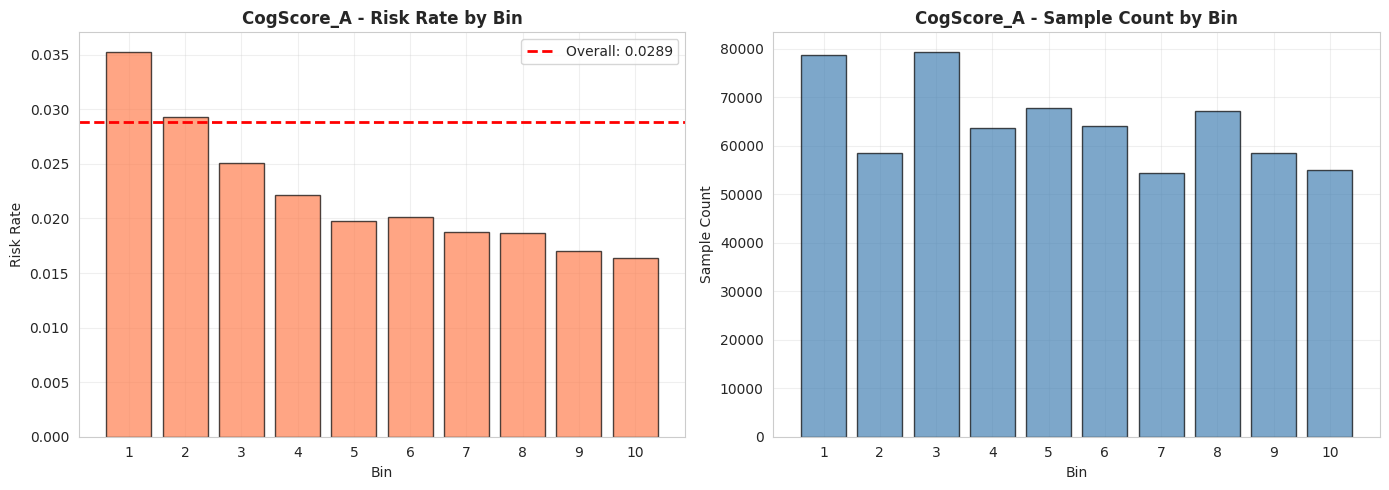


[Spike 구간 분석]
  - Low threshold: 1.00
  - High threshold: 20.00
  - Max risk rate: 0.0353


In [11]:
col = 'CogScore_A'
print(f"\n{'='*80}")
print(f"[A검사] {col} 구간 분석")
print(f"{'='*80}\n")

result = analyze_bins(A_df, col, bins=10, method='quantile')
if result is not None:
    print("\n[10분위 quantile 기준]")
    print(result[['bin', 'risk_rate', 'count', 'coverage', 'left', 'right']])
    plot_bin_analysis(result, col, overall_risk)
    
    thresholds = find_spike_threshold(result, spike_factor=1.5)
    if thresholds:
        print(f"\n[Spike 구간 분석]")
        print(f"  - Low threshold: {thresholds['low_threshold']:.2f}")
        print(f"  - High threshold: {thresholds['high_threshold']:.2f}")
        print(f"  - Max risk rate: {thresholds['max_risk_rate']:.4f}")

## 7. B검사 핵심 피처 구간 분석

### 7.1 B4_acc_rate


[B검사] B4_acc_rate 구간 분석


[10분위 quantile 기준]
              bin  risk_rate   count  coverage   left  right
0  (-0.001, 0.45]    0.04288   34654     11.65 -0.001  0.450
1   (0.45, 0.483]    0.04445   65402     21.98  0.450  0.483
2    (0.483, 0.5]    0.04151  197467     66.37  0.483  0.500


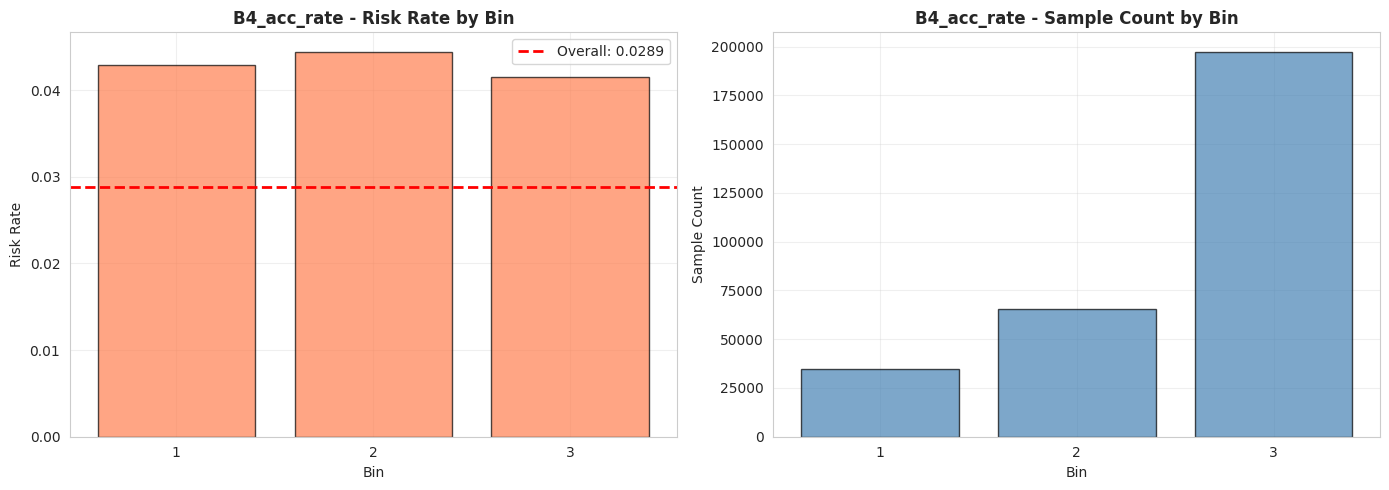

In [12]:
col = 'B4_acc_rate'
print(f"\n{'='*80}")
print(f"[B검사] {col} 구간 분석")
print(f"{'='*80}\n")

result = analyze_bins(B_df, col, bins=10, method='quantile')
if result is not None:
    print("\n[10분위 quantile 기준]")
    print(result[['bin', 'risk_rate', 'count', 'coverage', 'left', 'right']])
    plot_bin_analysis(result, col, overall_risk)
    
    thresholds = find_spike_threshold(result, spike_factor=1.3)
    if thresholds:
        print(f"\n[Spike 구간 분석]")
        print(f"  - Low threshold: {thresholds['low_threshold']:.4f}")
        print(f"  - High threshold: {thresholds['high_threshold']:.4f}")
        print(f"  - Max risk rate: {thresholds['max_risk_rate']:.4f}")

### 7.2 B4_rt_mean


[B검사] B4_rt_mean 구간 분석


[10분위 quantile 기준]
              bin  risk_rate  count  coverage   left   right
0  (0.428, 0.642]    0.04286  29793     10.01  0.428   0.642
1  (0.642, 0.675]    0.04121  29801     10.02  0.642   0.675
2  (0.675, 0.701]    0.04421  29721      9.99  0.675   0.701
3  (0.701, 0.726]    0.04312  29777     10.01  0.701   0.726
4  (0.726, 0.752]    0.04148  29677      9.97  0.726   0.752
5  (0.752, 0.782]    0.04378  29782     10.01  0.752   0.782
6  (0.782, 0.817]    0.04095  29717      9.99  0.782   0.817
7  (0.817, 0.866]    0.04299  29752     10.00  0.817   0.866
8  (0.866, 0.954]    0.04059  29761     10.00  0.866   0.954
9   (0.954, 10.0]    0.04196  29742     10.00  0.954  10.000


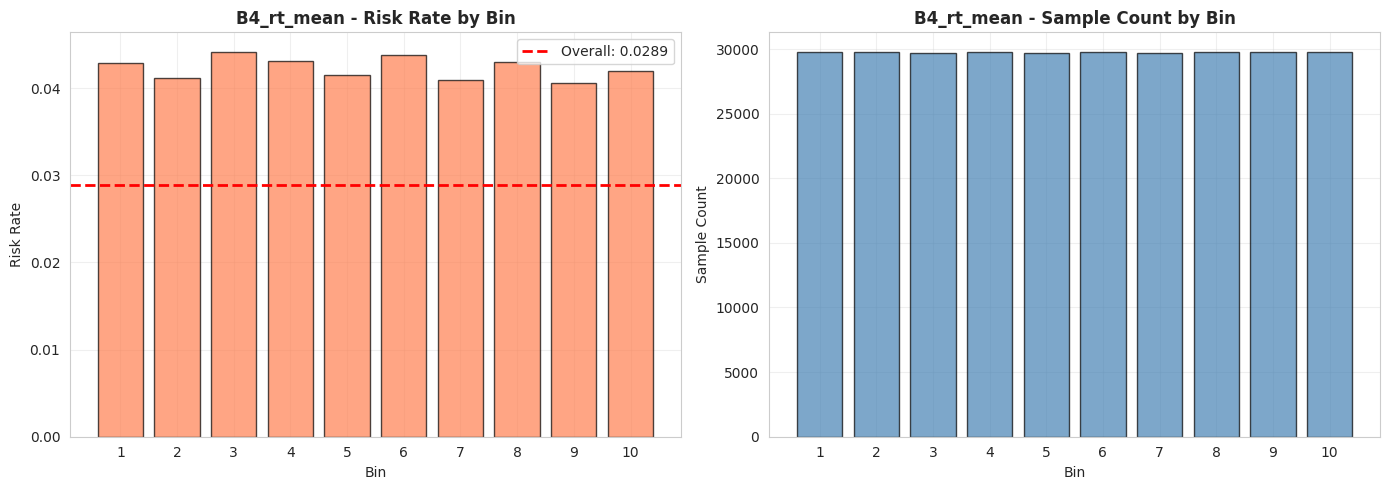

In [13]:
col = 'B4_rt_mean'
print(f"\n{'='*80}")
print(f"[B검사] {col} 구간 분석")
print(f"{'='*80}\n")

result = analyze_bins(B_df, col, bins=10, method='quantile')
if result is not None:
    print("\n[10분위 quantile 기준]")
    print(result[['bin', 'risk_rate', 'count', 'coverage', 'left', 'right']])
    plot_bin_analysis(result, col, overall_risk)
    
    thresholds = find_spike_threshold(result, spike_factor=1.3)
    if thresholds:
        print(f"\n[Spike 구간 분析]")
        print(f"  - Low threshold: {thresholds['low_threshold']:.2f} ms")
        print(f"  - High threshold: {thresholds['high_threshold']:.2f} ms")
        print(f"  - Max risk rate: {thresholds['max_risk_rate']:.4f}")

### 7.3 RiskScore_B


[B검사] RiskScore_B 구간 분석


[10분위 quantile 기준]
                   bin  risk_rate  count  coverage   left        right
0       (0.218, 0.325]    0.04023  29753      10.0  0.218        0.325
1       (0.325, 0.338]    0.04171  29753      10.0  0.325        0.338
2       (0.338, 0.348]    0.04070  29752      10.0  0.338        0.348
3       (0.348, 0.358]    0.04188  29753      10.0  0.348        0.358
4       (0.358, 0.369]    0.04259  29752      10.0  0.358        0.369
5       (0.369, 0.382]    0.04423  29753      10.0  0.369        0.382
6         (0.382, 0.4]    0.04339  29752      10.0  0.382        0.400
7          (0.4, 0.43]    0.04460  29753      10.0  0.400        0.430
8        (0.43, 0.501]    0.04218  29752      10.0  0.430        0.501
9  (0.501, 2500000.78]    0.04164  29753      10.0  0.501  2500000.780


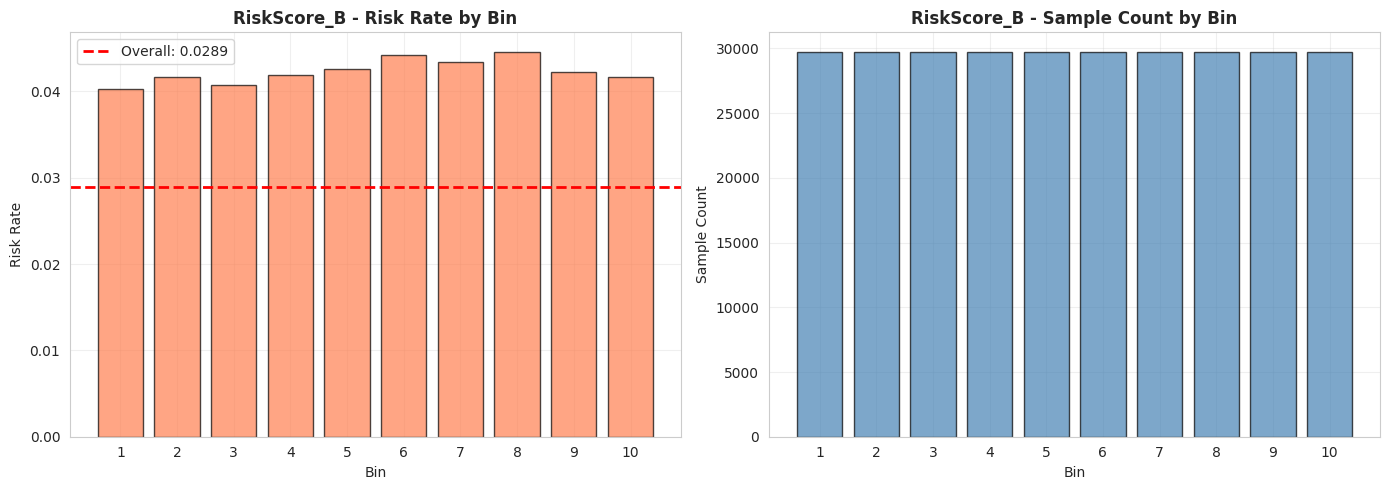

In [14]:
col = 'RiskScore_B'
print(f"\n{'='*80}")
print(f"[B검사] {col} 구간 분석")
print(f"{'='*80}\n")

result = analyze_bins(B_df, col, bins=10, method='quantile')
if result is not None:
    print("\n[10분위 quantile 기준]")
    print(result[['bin', 'risk_rate', 'count', 'coverage', 'left', 'right']])
    plot_bin_analysis(result, col, overall_risk)
    
    thresholds = find_spike_threshold(result, spike_factor=1.3)
    if thresholds:
        print(f"\n[Spike 구간 분석]")
        print(f"  - Low threshold: {thresholds['low_threshold']:.4f}")
        print(f"  - High threshold: {thresholds['high_threshold']:.4f}")
        print(f"  - Max risk rate: {thresholds['max_risk_rate']:.4f}")

### 7.4 B10_multitask_cost_aud


[B검사] B10_multitask_cost_aud 구간 분석


[10분위 quantile 기준]
                 bin  risk_rate  count  coverage    left   right
0  (-0.761, -0.0875]    0.04861  31473     10.58 -0.7610 -0.0875
1   (-0.0875, -0.06]    0.04582  29310      9.85 -0.0875 -0.0600
2     (-0.06, -0.04]    0.04240  28491      9.58 -0.0600 -0.0400
3     (-0.04, -0.03]    0.04054  30411     10.22 -0.0400 -0.0300
4    (-0.03, -0.025]    0.03646  29430      9.89 -0.0300 -0.0250
5  (-0.025, -0.0125]    0.03904  42029     14.13 -0.0250 -0.0125
6     (-0.0125, 0.0]    0.03631  46242     15.54 -0.0125  0.0000
7      (0.0, 0.0025]    0.04483   3078      1.03  0.0000  0.0025
8     (0.0025, 0.04]    0.04052  28649      9.63  0.0025  0.0400
9       (0.04, 0.75]    0.05575  28413      9.55  0.0400  0.7500


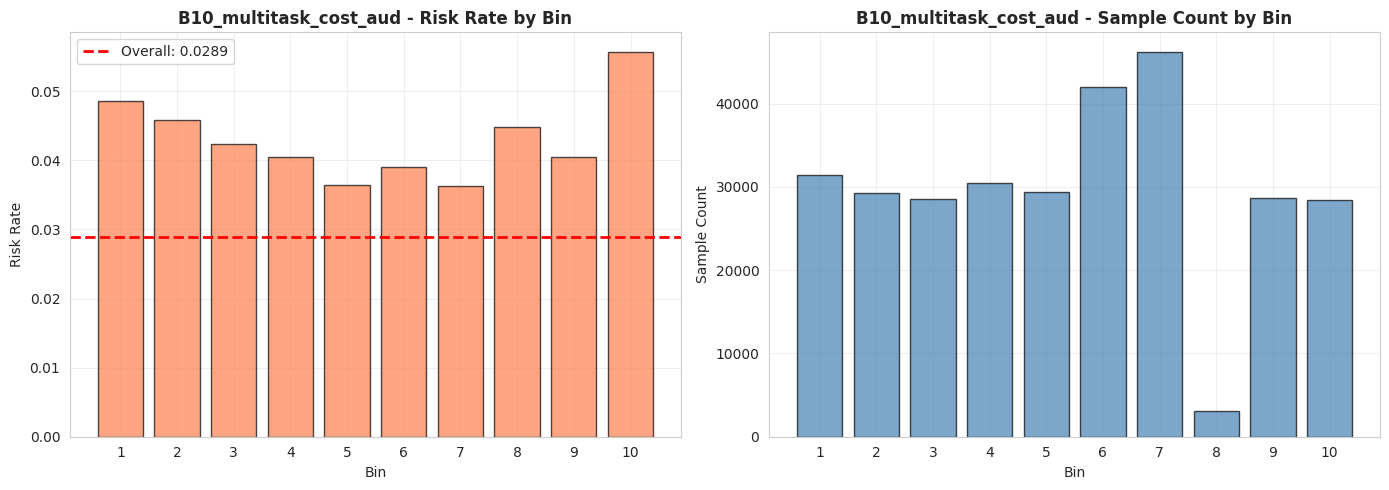

In [15]:
if 'B10_multitask_cost_aud' in B_df.columns:
    col = 'B10_multitask_cost_aud'
    print(f"\n{'='*80}")
    print(f"[B검사] {col} 구간 분석")
    print(f"{'='*80}\n")
    
    result = analyze_bins(B_df, col, bins=10, method='quantile')
    if result is not None:
        print("\n[10분위 quantile 기준]")
        print(result[['bin', 'risk_rate', 'count', 'coverage', 'left', 'right']])
        plot_bin_analysis(result, col, overall_risk)
        
        thresholds = find_spike_threshold(result, spike_factor=1.3)
        if thresholds:
            print(f"\n[Spike 구간 분석]")
            print(f"  - Low threshold: {thresholds['low_threshold']:.4f}")
            print(f"  - High threshold: {thresholds['high_threshold']:.4f}")
            print(f"  - Max risk rate: {thresholds['max_risk_rate']:.4f}")
else:
    print("B10_multitask_cost_aud 컬럼 없음")

## 8. Indicator Feature 생성 (예시)

### 8.1 A검사 Indicator Features

In [16]:
print("\n" + "="*80)
print("[A검사] Indicator Features 생성")
print("="*80 + "\n")

# 위 분석 결과를 바탕으로 threshold 설정 (예시 - 실제 실행 후 조정 필요)
# A4_acc_rate < 0.8이면 high risk로 가정
A_df['A4_low_acc_flag'] = (A_df['A4_acc_rate'] < 0.8).astype(int)

# A4_stroop_diff > 상위 25%이면 high risk
stroop_threshold = A_df['A4_stroop_diff'].quantile(0.75)
A_df['A4_high_stroop_flag'] = (A_df['A4_stroop_diff'] > stroop_threshold).astype(int)

# A1_rt_mean > 상위 25%
rt_threshold = A_df['A1_rt_mean'].quantile(0.75)
A_df['A1_slow_rt_flag'] = (A_df['A1_rt_mean'] > rt_threshold).astype(int)

# CogScore_A < 하위 25%
cog_threshold = A_df['CogScore_A'].quantile(0.25)
A_df['A_low_cog_flag'] = (A_df['CogScore_A'] < cog_threshold).astype(int)

# 각 flag의 효과 검증
indicators_A = ['A4_low_acc_flag', 'A4_high_stroop_flag', 'A1_slow_rt_flag', 'A_low_cog_flag']

print("\n[각 Indicator의 위험비율]\n")
for ind in indicators_A:
    if ind in A_df.columns:
        risk_by_flag = A_df.groupby(ind)['Label'].agg(['mean', 'count'])
        print(f"\n{ind}:")
        print(risk_by_flag)
        print(f"  → Flag=1일 때 위험비율: {risk_by_flag.loc[1, 'mean']:.4f} (vs 전체: {overall_risk:.4f})")
        print(f"  → Flag=1 커버리지: {risk_by_flag.loc[1, 'count']} / {len(A_df)} ({risk_by_flag.loc[1, 'count']/len(A_df)*100:.2f}%)")


[A검사] Indicator Features 생성


[각 Indicator의 위험비율]


A4_low_acc_flag:
                     mean   count
A4_low_acc_flag                  
0                0.022675  646825
1                0.060096     416
  → Flag=1일 때 위험비율: 0.0601 (vs 전체: 0.0289)
  → Flag=1 커버리지: 416 / 647241 (0.06%)

A4_high_stroop_flag:
                         mean   count
A4_high_stroop_flag                  
0                    0.021820  485607
1                    0.025341  161634
  → Flag=1일 때 위험비율: 0.0253 (vs 전체: 0.0289)
  → Flag=1 커버리지: 161634 / 647241 (24.97%)

A1_slow_rt_flag:
                     mean   count
A1_slow_rt_flag                  
0                0.022288  485460
1                0.023934  161781
  → Flag=1일 때 위험비율: 0.0239 (vs 전체: 0.0289)
  → Flag=1 커버리지: 161781 / 647241 (25.00%)

A_low_cog_flag:
                    mean   count
A_low_cog_flag                  
0               0.019613  485890
1               0.031992  161351
  → Flag=1일 때 위험비율: 0.0320 (vs 전체: 0.0289)
  → Flag=1 커버리지: 161351

### 8.2 B검사 Indicator Features

In [17]:
print("\n" + "="*80)
print("[B검사] Indicator Features 생성")
print("="*80 + "\n")

# B4_acc_rate < 0.85
B_df['B4_low_acc_flag'] = (B_df['B4_acc_rate'] < 0.85).astype(int)

# B4_rt_mean > 상위 25%
b4_rt_threshold = B_df['B4_rt_mean'].quantile(0.75)
B_df['B4_slow_rt_flag'] = (B_df['B4_rt_mean'] > b4_rt_threshold).astype(int)

# RiskScore_B > 상위 25%
risk_threshold = B_df['RiskScore_B'].quantile(0.75)
B_df['B_high_risk_flag'] = (B_df['RiskScore_B'] > risk_threshold).astype(int)

indicators_B = ['B4_low_acc_flag', 'B4_slow_rt_flag', 'B_high_risk_flag']

print("\n[각 Indicator의 위험비율]\n")
for ind in indicators_B:
    if ind in B_df.columns:
        risk_by_flag = B_df.groupby(ind)['Label'].agg(['mean', 'count'])
        print(f"\n{ind}:")
        print(risk_by_flag)
        if 1 in risk_by_flag.index:
            print(f"  → Flag=1일 때 위험비율: {risk_by_flag.loc[1, 'mean']:.4f} (vs 전체: {overall_risk:.4f})")
            print(f"  → Flag=1 커버리지: {risk_by_flag.loc[1, 'count']} / {len(B_df)} ({risk_by_flag.loc[1, 'count']/len(B_df)*100:.2f}%)")


[B검사] Indicator Features 생성


[각 Indicator의 위험비율]


B4_low_acc_flag:
                     mean   count
B4_low_acc_flag                  
0                0.000000       3
1                0.042316  297523
  → Flag=1일 때 위험비율: 0.0423 (vs 전체: 0.0289)
  → Flag=1 커버리지: 297523 / 297526 (100.00%)

B4_slow_rt_flag:
                     mean   count
B4_slow_rt_flag                  
0                0.042531  223154
1                0.041669   74372
  → Flag=1일 때 위험비율: 0.0417 (vs 전체: 0.0289)
  → Flag=1 커버리지: 74372 / 297526 (25.00%)

B_high_risk_flag:
                      mean   count
B_high_risk_flag                  
0                 0.042233  223144
1                 0.042564   74382
  → Flag=1일 때 위험비율: 0.0426 (vs 전체: 0.0289)
  → Flag=1 커버리지: 74382 / 297526 (25.00%)


## 9. Age 복합 조건 분석

### 9.1 Age bin 정의

In [18]:
def age_bin(age):
    if pd.isna(age):
        return 'Unknown'
    elif age < 50:
        return '<50'
    elif age < 60:
        return '50-59'
    else:
        return '60+'

A_df['Age_bin'] = A_df['Age_num'].apply(age_bin)
B_df['Age_bin'] = B_df['Age_num'].apply(age_bin)

print("Age bin 생성 완료")

Age bin 생성 완료


### 9.2 A검사: Age × Indicator 교차 분석

In [19]:
print("\n" + "="*80)
print("[A검사] Age × Indicator 교차 분석")
print("="*80 + "\n")

# Age_bin × A4_low_acc_flag
if 'A4_low_acc_flag' in A_df.columns:
    print("\n[Age_bin × A4_low_acc_flag]\n")
    cross = pd.crosstab(
        A_df['Age_bin'], 
        A_df['A4_low_acc_flag'],
        A_df['Label'],
        aggfunc='mean',
        margins=True
    )
    print("위험비율:")
    print(cross.round(4))
    
    count = pd.crosstab(
        A_df['Age_bin'],
        A_df['A4_low_acc_flag'],
        margins=True
    )
    print("\n샘플 수:")
    print(count)
    
    # 복합 조건 만들기
    A_df['Old_and_low_A4'] = (
        (A_df['Age_num'] >= 60) & (A_df['A4_low_acc_flag'] == 1)
    ).astype(int)
    
    print("\n[복합 조건: Old_and_low_A4 (Age>=60 & A4_low_acc)]")
    complex_risk = A_df.groupby('Old_and_low_A4')['Label'].agg(['mean', 'count'])
    print(complex_risk)
    if 1 in complex_risk.index:
        print(f"  → 복합조건 만족 시 위험비율: {complex_risk.loc[1, 'mean']:.4f}")
        print(f"  → 전체 대비 증가: {(complex_risk.loc[1, 'mean'] / overall_risk - 1) * 100:.1f}%")


[A검사] Age × Indicator 교차 분석


[Age_bin × A4_low_acc_flag]

위험비율:
A4_low_acc_flag       0       1     All
Age_bin                                
50-59            0.0226  0.0370  0.0226
60+              0.0555  0.0922  0.0555
<50              0.0137  0.0133  0.0137
All              0.0227  0.0601  0.0227

샘플 수:
A4_low_acc_flag       0    1     All
Age_bin                             
50-59            189866  135  190001
60+               98538  206   98744
<50              358421   75  358496
All              646825  416  647241

[복합 조건: Old_and_low_A4 (Age>=60 & A4_low_acc)]
                    mean   count
Old_and_low_A4                  
0               0.022677  647035
1               0.092233     206
  → 복합조건 만족 시 위험비율: 0.0922
  → 전체 대비 증가: 219.4%


### 9.3 B검사: Age × Indicator 교차 분석

In [20]:
print("\n" + "="*80)
print("[B검사] Age × Indicator 교차 분석")
print("="*80 + "\n")

# Age_bin × B4_low_acc_flag
if 'B4_low_acc_flag' in B_df.columns:
    print("\n[Age_bin × B4_low_acc_flag]\n")
    cross = pd.crosstab(
        B_df['Age_bin'],
        B_df['B4_low_acc_flag'],
        B_df['Label'],
        aggfunc='mean',
        margins=True
    )
    print("위험비율:")
    print(cross.round(4))
    
    count = pd.crosstab(
        B_df['Age_bin'],
        B_df['B4_low_acc_flag'],
        margins=True
    )
    print("\n샘플 수:")
    print(count)
    
    # 복합 조건
    B_df['Old_and_low_B4'] = (
        (B_df['Age_num'] >= 60) & (B_df['B4_low_acc_flag'] == 1)
    ).astype(int)
    
    print("\n[복합 조건: Old_and_low_B4 (Age>=60 & B4_low_acc)]")
    complex_risk = B_df.groupby('Old_and_low_B4')['Label'].agg(['mean', 'count'])
    print(complex_risk)
    if 1 in complex_risk.index:
        print(f"  → 복합조건 만족 시 위험비율: {complex_risk.loc[1, 'mean']:.4f}")
        print(f"  → 전체 대비 증가: {(complex_risk.loc[1, 'mean'] / overall_risk - 1) * 100:.1f}%")


[B검사] Age × Indicator 교차 분석


[Age_bin × B4_low_acc_flag]

위험비율:
B4_low_acc_flag    0       1     All
Age_bin                             
60+              0.0  0.0423  0.0423
All              0.0  0.0423  0.0423

샘플 수:
B4_low_acc_flag  0       1     All
Age_bin                           
60+              3  297523  297526
All              3  297523  297526

[복합 조건: Old_and_low_B4 (Age>=60 & B4_low_acc)]
                    mean   count
Old_and_low_B4                  
0               0.000000       3
1               0.042316  297523
  → 복합조건 만족 시 위험비율: 0.0423
  → 전체 대비 증가: 46.5%


## 10. Age 인터랙션 피처 생성

In [21]:
print("\n" + "="*80)
print("Age 인터랙션 피처 생성")
print("="*80 + "\n")

# A검사
print("[A검사 인터랙션]")
A_df['Age_x_A4_stroop'] = A_df['Age_num'] * A_df['A4_stroop_diff']
A_df['Age_x_A4_acc_inv'] = A_df['Age_num'] * (1 - A_df['A4_acc_rate'].fillna(0))
A_df['Age_x_A5_gap'] = A_df['Age_num'] * A_df['A5_change_nonchange_gap']
A_df['Age_x_CogScore'] = A_df['Age_num'] * A_df['CogScore_A']

age_interactions_A = ['Age_x_A4_stroop', 'Age_x_A4_acc_inv', 'Age_x_A5_gap', 'Age_x_CogScore']
for feat in age_interactions_A:
    if feat in A_df.columns:
        corr = A_df[['Label', feat]].corr().loc['Label', feat]
        print(f"  {feat}: Label 상관 = {corr:.5f}")

# B검사
print("\n[B검사 인터랙션]")
B_df['Age_x_B4_acc_inv'] = B_df['Age_num'] * (1 - B_df['B4_acc_rate'].fillna(0))
B_df['Age_x_B4_rt'] = B_df['Age_num'] * B_df['B4_rt_mean']
B_df['Age_x_RiskScore'] = B_df['Age_num'] * B_df['RiskScore_B']
if 'B10_multitask_cost_aud' in B_df.columns:
    B_df['Age_x_B10_multitask'] = B_df['Age_num'] * B_df['B10_multitask_cost_aud']

age_interactions_B = ['Age_x_B4_acc_inv', 'Age_x_B4_rt', 'Age_x_RiskScore']
if 'Age_x_B10_multitask' in B_df.columns:
    age_interactions_B.append('Age_x_B10_multitask')

for feat in age_interactions_B:
    if feat in B_df.columns:
        corr = B_df[['Label', feat]].corr().loc['Label', feat]
        print(f"  {feat}: Label 상관 = {corr:.5f}")

print("\nAge 인터랙션 피처 생성 완료!")


Age 인터랙션 피처 생성

[A검사 인터랙션]
  Age_x_A4_stroop: Label 상관 = 0.01778
  Age_x_A4_acc_inv: Label 상관 = 0.02582
  Age_x_A5_gap: Label 상관 = 0.03155
  Age_x_CogScore: Label 상관 = 0.02334

[B검사 인터랙션]
  Age_x_B4_acc_inv: Label 상관 = -0.00014
  Age_x_B4_rt: Label 상관 = -0.00152
  Age_x_RiskScore: Label 상관 = -0.00167
  Age_x_B10_multitask: Label 상관 = 0.00017

Age 인터랙션 피처 생성 완료!


## 11. 최종 피처 리스트 및 script04 통합 코드

In [ ]:
print("\n" + "="*80)
print("최종 추가 피처 리스트")
print("="*80 + "\n")

print("[A검사 추가 피처]")
print("""
1. Age 관련:
   - Age_bin (더미 변수로 변환)
   - Age_z

2. Indicator Features:
   - A4_low_acc_flag
   - A4_high_stroop_flag
   - A1_slow_rt_flag
   - A_low_cog_flag

3. 복합 조건:
   - Old_and_low_A4

4. Age 인터랙션:
   - Age_x_A4_stroop
   - Age_x_A4_acc_inv
   - Age_x_A5_gap
   - Age_x_CogScore

5. 기존 피처 유지:
   - CogScore_A, EmoScore_A
   - A5_change_nonchange_gap
""")

print("\n[B검사 추가 피처]")
print("""
1. Age 관련:
   - Age_bin (더미 변수로 변환)
   - Age_z

2. Indicator Features:
   - B4_low_acc_flag
   - B4_slow_rt_flag
   - B_high_risk_flag

3. 복합 조건:
   - Old_and_low_B4

4. Age 인터랙션:
   - Age_x_B4_acc_inv
   - Age_x_B4_rt
   - Age_x_RiskScore
   - Age_x_B10_multitask (if available)

5. 기존 피처 유지:
   - RiskScore_B
   - B10_multitask_cost_aud/vis
""")


최종 추가 피처 리스트

[A검사 추가 피처]

1. Age 관련:
   - Age_bin (더미 변수로 변환)
   - Age_z

2. Indicator Features:
   - A4_low_acc_flag
   - A4_high_stroop_flag
   - A1_slow_rt_flag
   - A_low_cog_flag

3. 복합 조건:
   - Old_and_low_A4

4. Age 인터랙션:
   - Age_x_A4_stroop
   - Age_x_A4_acc_inv
   - Age_x_A5_gap
   - Age_x_CogScore

5. 기존 피처 유지:
   - CogScore_A, EmoScore_A
   - A5_change_nonchange_gap


[B검사 추가 피처]

1. Age 관련:
   - Age_bin (더미 변수로 변환)
   - Age_z

2. Indicator Features:
   - B4_low_acc_flag
   - B4_slow_rt_flag
   - B_high_risk_flag

3. 복합 조건:
   - Old_and_low_B4

4. Age 인터랙션:
   - Age_x_B4_acc_inv
   - Age_x_B4_rt
   - Age_x_RiskScore
   - Age_x_B10_multitask (if available)

5. 기존 피처 유지:
   - RiskScore_B
   - B10_multitask_cost_aud/vis



: 

### 11.1 script04.py 통합 코드 (복사용)

In [ ]:
print("""
# ============================================================
# script04.py의 add_features_A()에 추가할 코드
# ============================================================

def add_features_A(df: pd.DataFrame) -> pd.DataFrame:
    feats = df.copy()
    eps = 1e-6
    
    # ... (기존 코드)
    
    # ===== 새로 추가 =====
    
    # 1. Age_z
    if 'Age_num' in feats.columns:
        age_mean = feats['Age_num'].mean()
        age_std = feats['Age_num'].std()
        feats['Age_z'] = (feats['Age_num'] - age_mean) / (age_std + eps)
    
    # 2. Indicator flags (threshold는 분석 결과 기반 조정)
    if 'A4_acc_rate' in feats.columns:
        feats['A4_low_acc_flag'] = (feats['A4_acc_rate'] < 0.8).astype(int)
    
    if 'A4_stroop_diff' in feats.columns:
        stroop_threshold = feats['A4_stroop_diff'].quantile(0.75)
        feats['A4_high_stroop_flag'] = (feats['A4_stroop_diff'] > stroop_threshold).astype(int)
    
    if 'A1_rt_mean' in feats.columns:
        rt_threshold = feats['A1_rt_mean'].quantile(0.75)
        feats['A1_slow_rt_flag'] = (feats['A1_rt_mean'] > rt_threshold).astype(int)
    
    # 3. Age 인터랙션 (기존 Age_x_A1_RT 외 추가)
    if _has(feats, ['Age_num', 'A4_stroop_diff']):
        feats['Age_x_A4_stroop'] = feats['Age_num'] * feats['A4_stroop_diff']
    
    if _has(feats, ['Age_num', 'A4_acc_rate']):
        feats['Age_x_A4_acc_inv'] = feats['Age_num'] * (1 - feats['A4_acc_rate'].fillna(0))
    
    if _has(feats, ['Age_num', 'A5_change_nonchange_gap']):
        feats['Age_x_A5_gap'] = feats['Age_num'] * feats['A5_change_nonchange_gap']
    
    # 4. 복합 조건
    if _has(feats, ['Age_num', 'A4_low_acc_flag']):
        feats['Old_and_low_A4'] = (
            (feats['Age_num'] >= 60) & (feats['A4_low_acc_flag'] == 1)
        ).astype(int)
    
    feats.replace([np.inf, -np.inf], np.nan, inplace=True)
    return feats

# ============================================================
# script04.py의 add_features_B()에 추가할 코드
# ============================================================

def add_features_B(df: pd.DataFrame) -> pd.DataFrame:
    feats = df.copy()
    eps = 1e-6
    
    # ... (기존 코드)
    
    # ===== 새로 추가 =====
    
    # 1. Age_z
    if 'Age_num' in feats.columns:
        age_mean = feats['Age_num'].mean()
        age_std = feats['Age_num'].std()
        feats['Age_z'] = (feats['Age_num'] - age_mean) / (age_std + eps)
    
    # 2. Indicator flags
    if 'B4_acc_rate' in feats.columns:
        feats['B4_low_acc_flag'] = (feats['B4_acc_rate'] < 0.85).astype(int)
    
    if 'B4_rt_mean' in feats.columns:
        b4_rt_threshold = feats['B4_rt_mean'].quantile(0.75)
        feats['B4_slow_rt_flag'] = (feats['B4_rt_mean'] > b4_rt_threshold).astype(int)
    
    if 'RiskScore_B' in feats.columns:
        risk_threshold = feats['RiskScore_B'].quantile(0.75)
        feats['B_high_risk_flag'] = (feats['RiskScore_B'] > risk_threshold).astype(int)
    
    # 3. Age 인터랙션
    if _has(feats, ['Age_num', 'B4_acc_rate']):
        feats['Age_x_B4_acc_inv'] = feats['Age_num'] * (1 - feats['B4_acc_rate'].fillna(0))
    
    if _has(feats, ['Age_num', 'B4_rt_mean']):
        feats['Age_x_B4_rt'] = feats['Age_num'] * feats['B4_rt_mean']
    
    if _has(feats, ['Age_num', 'RiskScore_B']):
        feats['Age_x_RiskScore'] = feats['Age_num'] * feats['RiskScore_B']
    
    if _has(feats, ['Age_num', 'B10_multitask_cost_aud']):
        feats['Age_x_B10_multitask'] = feats['Age_num'] * feats['B10_multitask_cost_aud']
    
    # 4. 복합 조건
    if _has(feats, ['Age_num', 'B4_low_acc_flag']):
        feats['Old_and_low_B4'] = (
            (feats['Age_num'] >= 60) & (feats['B4_low_acc_flag'] == 1)
        ).astype(int)
    
    feats.replace([np.inf, -np.inf], np.nan, inplace=True)
    return feats
""")

## 12. 요약

In [ ]:
print("\n" + "="*80)
print("분석 완료 요약")
print("="*80 + "\n")

print("""
✅ 완료한 작업:

1. 핵심 피처별 구간 분석 (10분위 quantile)
   - 위험비율이 튀는 구간 식별
   - Threshold 자동 탐지 (spike_factor 활용)

2. Indicator Feature 생성
   - A검사: A4_low_acc_flag, A4_high_stroop_flag, A1_slow_rt_flag 등
   - B검사: B4_low_acc_flag, B4_slow_rt_flag, B_high_risk_flag 등
   - 각 flag의 효과 검증 (위험비율, 커버리지)

3. Age 복합 조건
   - Age_bin × Indicator 교차 분석
   - Old_and_low_A4, Old_and_low_B4 등 복합 flag 생성

4. Age 인터랙션 피처
   - Age × 핵심 점수 (stroop, acc, RiskScore 등)
   - Label과의 상관계수 확인

📋 다음 단계:

1. 이 노트북 실행 후 실제 threshold 값 확인
2. 위 코드를 script04.py에 통합
3. 모델 재학습 및 Holdout AUC 비교
   - A 검사: 기존 AUC vs 새 피처 AUC
   - B 검사: 0.59 → 0.60+ 목표
4. Feature importance 확인 후 불필요한 피처 제거
5. 최종 제출

💡 핵심 인사이트:
- 구간별 위험비율을 보면 "어디서 튀는지" 명확히 보임
- Indicator feature는 모델이 비선형 패턴을 더 쉽게 학습하도록 도움
- Age는 단독보다는 성능 지표와 조합할 때 더 강력
""")

print("\n🎉 분석 완료!")